# FitAndPlot

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import rv_histogram
import corner
import HaloReadH5
import os

In [3]:
#Define G
G_mpc = 4.302e-9    #In Msun^-1 * Mpc * km^2 * s^-2

### Global code parameters

Set these parameters to change the behavior of the routine on a global scale. Otherwise, the individual arguments of a given function can be specifically changed directly in the function call.

In [91]:
#Simulation parameters
#---------------------
#Path of the directory containing the simulation folders, including "/" at the end (see README)
hdf5_folder = "SIM/"
#Name of the simulation, assigned to the top-level directory (see README)
simulation_name = "PATHFINDER"
#Names of the individual simulation models (see README)
simulation_type = ["LCDM", "fR5", "fR5_1eV", "fR5_15eV"]
#Names of the region folders to read and corresponding maximum number of files to read in each, leave the region list as [""] for no regions
#The number of files can be a list specifying the number of files to read in each individual region folder, leave None to read every file
files_to_read = (["z05"], None)
#List of dimensions along which to consider the 2D profiles for reading and fitting, e.g. ["x", "y", "z"]
projections = ["x"]
#Divide the simulations in batches to analyse separately, only used in the analysis section (if present, put the LCDM model in every batch first)
#Leave as [simulation_type] for no batches
simulation_batches = [simulation_type]

#Fitting parameters
#------------------
#List of dimensions to consider when fitting, e.g. ["3D", "2D"]
fit_dimensions_num = ["3D", "2D"]
#List of profile models to fit in the 3D and 2D cases, e.g. ["NFW", "gNFW"]
fit_profiles_3D = ["NFW"]
fit_profiles_2D = ["NFW"]
#List of halo profile types to fit in the 3D and 2D cases, e.g. ["MASS", "DENSITY"]
fit_quantities_3D = ["MASS"]
fit_quantities_2D = ["MASS"]
#List of radial intervals for fitting the 3D and 2D profiles, each tuple contains the lower and upper radii for each fit model
radius_fit_bounds_3D = [(0.2, 1.5), (0.075, 1.5)]
radius_fit_bounds_2D = [(0.2, 1.5), (0.075, 1.5)]

#Constraint parameters
#---------------------
#Used in the "constraint" section to set a lower limit to the mass of the sample in each simulation. 
#Thus, only halos with M200_NFW > M_th are considered in the analysis
M_th = 1e13

#File reading and saving parameters
#----------------------------------
#Enable multiprocessing for reading and fitting (see README)
enable_multiprocessing = False
#Enable savestates for reading and fitting (see README)
enable_savestates = True
#Set to True to save the halo profiles, properties and fitting parameters to file once reading and fitting is complete
#The path to save the data to can also be specified, leave None to save to the default path (/progress/simulation_name)
save_data = True
save_data_path = None
#Set to True to load halo profiles, properties and fitting parameters from file instead of reading and fitting from zero
#Only useful if the data was saved using save_data was enabled prior
load_from_file = True

#Plotting parameters
save_plots = True
show_plots = True
fig_path = "figures/" + simulation_name
names_list = ["$\Lambda$CDM", r"$f_5(R)$", r"$f_5(R),\ m_\nu = 0.1\ eV$", r"$f_5(R),\ m_\nu = 0.15\ eV$"]
model_names = {sim_type: name for sim_type, name in zip(simulation_type, names_list)}

#Define the folder where all figures are saved
if save_plots:
    distdir = os.getcwd()

    for sim_type in simulation_type:
        fig_dir = fig_path + "/" + simulation_name 
        dirtot = os.path.join(distdir, fig_dir + "/" + sim_type)
        
        #If the directory doesn't exist, create it
        if not os.path.exists(dirtot):
            os.makedirs(dirtot)

#Disable interactive figures, if enabled
if show_plots:
    plt.ion()

else:
    plt.ioff()

### Read the 3D and 2D profiles

Main function used to read the 3D and 2D profiles, see HaloReadH5 for more details.

In [93]:
if __name__ == "__main__":
    halo_profiles,\
    halo_props,\
    sim_props = HaloReadH5.GetSimProfiles(hdf5_folder, simulation_name, simulation_type, sim_regions=files_to_read[0], dimensions=projections,
                                         save_to_file=save_data, load_from_file=load_from_file, save_data_path=save_data_path, 
                                         enable_savestates=enable_savestates, Ntoread=files_to_read[1],
                                         enable_multiprocessing=enable_multiprocessing, scale_lengths="r500")

    #Define new dictionaries to store the halo profiles in a more clear way
    #All dictionaries have the same keys as the original ones, except for the "3D" and "2D" keys
    halo_profiles_3D = {sim_type: halo_profiles[sim_type]["3D"] for sim_type in simulation_type}
    halo_profiles_2D = {sim_type: halo_profiles[sim_type]["2D"] for sim_type in simulation_type}
    
    halo_props_cut = halo_props.copy()
    sim_props_cut = sim_props.copy()

### Fit the 3D and 2D profiles

Main function used to fit the 3D and 2D profiles, see HaloReadH5 for more details.

In [95]:
if __name__ == "__main__":
    fit_pars, fit_cov = HaloReadH5.FitSimProfilesMP(halo_profiles, halo_props, sim_props, simulation_type, simulation_name,
                                                      profile_type_3D=fit_profiles_3D, profile_type_2D=fit_profiles_2D, 
                                                      fit_quantities_3D=fit_quantities_3D, fit_quantities_2D=fit_quantities_2D,
                                                      radius_fit_bounds_3D=radius_fit_bounds_3D, radius_fit_bounds_2D=radius_fit_bounds_2D,
                                                      n_dim_fits=fit_dimensions_num, dimensions=projections,
                                                      save_to_file=save_data, load_from_file=load_from_file, save_data_path=save_data_path, 
                                                      enable_savestates=enable_savestates, enable_multiprocessing=enable_multiprocessing)

    #Define new dictionaries to store the halo fits in a more clear way
    #All dictionaries have the same keys as the original ones, except for the "3D" and "2D" keys
    fit_pars_3D = {sim_type: fit_pars[sim_type]["3D"] for sim_type in simulation_type}
    fit_cov_3D = {sim_type: fit_cov[sim_type]["3D"] for sim_type in simulation_type}
    fit_pars_2D = {sim_type: fit_pars[sim_type]["2D"] for sim_type in simulation_type}
    fit_cov_2D = {sim_type: fit_cov[sim_type]["2D"] for sim_type in simulation_type}

### Apply constraints on the dataset

Apply a condition on every simulation considered, e.g. selecting only halos in each sample with mass greater than a threshold. Change the condition using the "cond" variable below.

In [97]:
#Define new dictionaries to store the new halo profiles, fits and properties after applying the condition
#All dictionaries have the same keys as the original ones, except for the "3D" and "2D" keys
halo_profiles_3D = {sim_type: dict() for sim_type in simulation_type}
fit_pars_3D = {sim_type: dict() for sim_type in simulation_type}
fit_cov_3D = {sim_type: dict() for sim_type in simulation_type}

halo_profiles_2D = {sim_type: dict() for sim_type in simulation_type}
fit_pars_2D = {sim_type: dict() for sim_type in simulation_type}
fit_cov_2D = {sim_type: dict() for sim_type in simulation_type}

halo_props_cut = {sim_type: dict() for sim_type in simulation_type}
sim_props_cut = {sim_type: dict() for sim_type in simulation_type}

for sim_type in simulation_type:
    lr200 = fit_pars[sim_type]["3D"]["NFW"]["MASS"]["r200"]
    lrs = fit_pars[sim_type]["3D"]["NFW"]["MASS"]["rs"]
    M200 = fit_pars[sim_type]["3D"]["NFW"]["MASS"]["M200"]
    chi2 = fit_pars[sim_type]["3D"]["NFW"]["MASS"]["chi2"]
    # M200 = halo_props[sim_type]["M200"]

    #Define the condition to select which halos to keep
    #-----------------------------------------------------#
    cond = (M200 > M_th) & (chi2 < np.inf)
    #-----------------------------------------------------#
    
    #Apply the set condition
    profiles, pars, cov,\
    hprops, sprops = HaloReadH5.ApplyCondition(halo_profiles, fit_pars=fit_pars, fit_cov=fit_cov, 
                                               halo_props=halo_props, sim_props=sim_props, condition=cond, sim_type=sim_type, dimensions=projections)

    halo_profiles_3D[sim_type] = profiles[sim_type]["3D"]
    halo_profiles_2D[sim_type] = profiles[sim_type]["2D"]

    if "3D" in fit_dimensions_num:
        fit_pars_3D[sim_type] = pars[sim_type]["3D"]
        fit_cov_3D[sim_type] = cov[sim_type]["3D"]

    if "2D" in fit_dimensions_num:
        fit_pars_2D[sim_type] = pars[sim_type]["2D"]
        fit_cov_2D[sim_type] = cov[sim_type]["2D"]

    halo_props_cut[sim_type] = hprops[sim_type]
    sim_props_cut[sim_type] = sprops[sim_type]

## Analysis of the simulations

#### Number of halos

Show the total number of halos in each simulation type, along with the number of halos remaining after applying the condition ("saved halos").

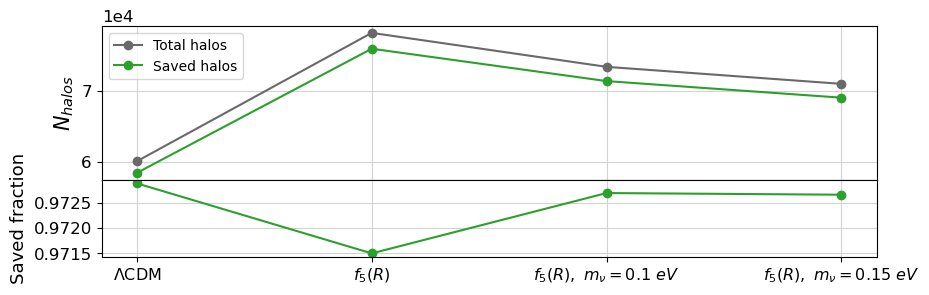

In [21]:
if len(simulation_type) > 1:
    fig_N, ax_N = plt.subplots(2, 1, figsize=(10, 3), sharex=True, gridspec_kw={"height_ratios": [2, 1]})
    
    N_cut = np.array([sim_props_cut[sim_type]["HALO_NUM_TOT"] for sim_type in simulation_type])
    N_total = np.array([sim_props[sim_type]["HALO_NUM_TOT"] for sim_type in simulation_type])
    names = [model_names[sim_type] for sim_type in simulation_type]
    
    ax_N[0].plot(names, N_total, marker="o", label="Total halos", color="dimgrey")
    ax_N[0].plot(names, N_cut, marker="o", label="Saved halos", color="tab:green")
    ax_N[0].tick_params(axis="x", which="both", bottom=False, labelbottom=False)
    ax_N[0].tick_params(axis="y", which="both", labelsize=12)
    ax_N[0].set_ylabel("$N_{halos}$", size=15)
    ax_N[0].grid(color="lightgrey")
    ax_N[0].ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
    ax_N[0].legend()
    ax_N[0].yaxis.get_offset_text().set_fontsize(12)
    
    ax_N[1].plot(names, N_cut / N_total, marker="o", color="tab:green")
    ax_N[1].set_ylabel("Saved fraction", size=13)
    ax_N[1].grid(color="lightgrey")
    ax_N[1].tick_params(axis="x", which="both", labelsize=11.5)
    ax_N[1].tick_params(axis="y", which="both", labelsize=12)
    
    fig_N.subplots_adjust(hspace=0.)

    if save_plots:
        fig_N.savefig(fig_path + "/" + "saved_halos_num.pdf", dpi=300, bbox_inches="tight")

#### Random 3D profile fits

Display a set number of random fitted halo profiles from each simulation type, showing the binned profile, fit functions, NFW fit $r_{200}$ (grey line), $r_s$ (black line) and simulation $r_{500}$ (red line).

In [ ]:
#Number of halos to display in the plot
Nto_display = 10
#IDs of the random halos to display for each simulation, they are the same for both the 3D and 2D plots
rand_ids = {sim_type: np.random.choice(halo_props_cut[sim_type]["ID"], size=Nto_display, replace=False) for sim_type in simulation_type}

In [ ]:
for k, sim_type in enumerate(simulation_type):
    Nto_display_half = int(Nto_display / 2)
    cosm_params = sim_props_cut[sim_type]["COSM_PARS"]
    halo_ids = halo_props_cut[sim_type]["ID"]
    
    #Plot eight random fits
    rand_idx = np.array([np.where(halo_ids == ids)[0][0] for ids in rand_ids[sim_type]])

    #Plot for each fitted quantity
    for quantity in fit_quantities_3D:
        fig_p, ax_p = plt.subplots(2, Nto_display_half, figsize=(10 + Nto_display, 8), sharey=True, sharex=True)
        
        for r in [0, 1]:
            fig_p.tight_layout()
            fig_p.subplots_adjust(hspace=0., wspace=0.)
    
            if quantity == "MASS":
                fig_p.supylabel("$M(\!< r)\ [M_\odot]$", size=25, x=0.01)
    
            elif quantity == "DENSITY":
                fig_p.supylabel("$\\rho(r)\ [M_\odot / Mpc^3]$", size=25, x=0.01)
    
            elif quantity == "VCIRC":
                fig_p.supylabel("$v_{circ}(r)\ [km/s]$", size=25, x=0.01)
            
            fig_p.supxlabel("$r/r_{500}$", size=25, y=-0.017)
            fig_p.suptitle(simulation_name + " " + model_names[sim_type] + " 3D " + quantity.lower() + " fits", size=25, y=0.97)
            
            for i, k in zip(rand_idx[r * Nto_display_half:r * Nto_display_half + Nto_display_half], np.arange(0, Nto_display_half, dtype=int)):
                ax = ax_p[r, k]
                ax.axvline(1., ls = '--', color = 'red')
                ax.tick_params(axis="y", labelsize=23, size=5)
                ax.minorticks_on()

                if r == 0:
                    ax.tick_params(axis="x", which="both", bottom=True, labelbottom=True, direction="in", size=3)

                else:
                    ax.tick_params(axis="x", which="both", labelsize=23, size=3)
            
                #Plot the binned profiles
                r500 = halo_props_cut[sim_type]["R500"][i]
                binned_profile = halo_profiles_3D[sim_type][quantity][i, :]
                binned_err = halo_profiles_3D[sim_type]["ERR_" + quantity][i, :]
                num = halo_profiles_3D[sim_type]["NUM"][i, :]
                R = halo_profiles_3D[sim_type]["R"][i, :] * r500
                cond = (num != 0)

                #Plot each profile model fit
                for p_type in fit_profiles_3D:
                    halo_model = HaloReadH5.HaloModel(p_type)
                    lhalo_pars = [fit_pars_3D[sim_type][p_type][quantity][par_name][i] for par_name in halo_model.free_par_names]
                    
                    lr200 = fit_pars_3D[sim_type][p_type][quantity]["r200"][i]
                    lrs = fit_pars_3D[sim_type][p_type][quantity]["rs"][i]
                    chi2 = fit_pars_3D[sim_type][p_type][quantity]["chi2"][i]

                    if p_type == "NFW":
                        ax.axvline(10**lr200 / r500, ls = '--', color = 'grey')
                        ax.axvline(10**lrs / r500, ls = '--', color = 'black')
                    
                    ax.errorbar(R[cond] / r500, binned_profile[cond], yerr = binned_err[cond], fmt='d', barsabove = True, color = 'black')
                    ax.loglog(R[cond] / r500, halo_model.profile(np.log10(R[cond]), *lhalo_pars, cosm_params=cosm_params, quantity=quantity), 
                                                                                              label="$\chi_{" + p_type + "}^2$ = " + f"{chi2:.2f}")

                    ax.legend(prop={"size": 18})

        if save_plots:
            fig_p.savefig(fig_path + sim_type + "/" + "fit_profiles_" + sim_type + ".pdf", dpi=300, bbox_inches='tight')      

In [ ]:
for k, sim_type in enumerate(simulation_type):
    cosm_params = sim_props_cut[sim_type]["COSM_PARS"]
    halo_ids = halo_props_cut[sim_type]["ID"]
    
    #Plot eight random fits
    rand_idx = np.array([np.where(halo_ids == ids)[0][0] for ids in rand_ids[sim_type]])

    #Plot for each 2D projection
    for dim in projections:
        for quantity in fit_quantities_2D:
            fig_p, ax_p = plt.subplots(2, Nto_display_half, figsize=(10 + Nto_display, 8), sharey=True, sharex=True)
            
            for r in [0, 1]:
                fig_p.tight_layout()
                fig_p.subplots_adjust(hspace=0., wspace=0.)
        
                if quantity == "MASS":
                    fig_p.supylabel("$M_{proj}(\!< R)\ [M_\odot]$", size=25, x=0.01)
        
                elif quantity == "DENSITY":
                    fig_p.supylabel("$\Sigma(R)\ [M_\odot / Mpc^2]$", size=25, x=0.01)
                
                fig_p.supxlabel("$R/r_{500}$", size=25, y=-0.017)
                fig_p.suptitle(simulation_name + " " + model_names[sim_type] + " 2D" + dim + " " + quantity.lower() + " fits", size=25, y=0.97)
                
                for i, k in zip(rand_idx[r * Nto_display_half:r * Nto_display_half + Nto_display_half], np.arange(0, Nto_display_half, dtype=int)):
                    ax = ax_p[r, k]
                    ax.tick_params(axis="y", labelsize=23, size=5)
                    ax.minorticks_on()
    
                    if r == 0:
                        ax.tick_params(axis="x", which="both", bottom=True, labelbottom=True, direction="in", size=3)
    
                    else:
                        ax.tick_params(axis="x", which="both", labelsize=23, size=3)
                
                    #Plot the binned profiles
                    r500 = halo_props_cut[sim_type]["R500"][i]
                    binned_profile = halo_profiles_2D[sim_type][dim][quantity][i, :]
                    binned_err = halo_profiles_2D[sim_type][dim]["ERR_" + quantity][i, :]
                    num = halo_profiles_2D[sim_type][dim]["NUM"][i, :]
                    R = halo_profiles_2D[sim_type][dim]["R"][i, :] * r500
                    cond = (num != 0)

                    #Plot each profile model fit
                    for p_type in fit_profiles_2D:
                        halo_model = HaloReadH5.HaloModel(p_type)
                        lhalo_pars = [fit_pars_2D[sim_type][dim][p_type][quantity][par_name][i] for par_name in halo_model.free_par_names]
                        
                        lr200 = fit_pars_2D[sim_type][dim][p_type][quantity]["r200"][i]
                        lrs = fit_pars_2D[sim_type][dim][p_type][quantity]["rs"][i]
                        chi2 = fit_pars_2D[sim_type][dim][p_type][quantity]["chi2"][i]
                        
                        ax.errorbar(R[cond] / r500, binned_profile[cond], yerr = binned_err[cond], fmt='d', barsabove = True, color = 'black')
                        ax.loglog(R[cond] / r500, halo_model.profile(np.log10(R[cond]), *lhalo_pars, cosm_params=cosm_params, quantity=quantity,
                                                                                                  projection=True),
                                                                                                  label="$\chi_{" + p_type + "}^2$ = " + f"{chi2:.2f}")
    
                        ax.legend(prop={"size": 18})
    
            if save_plots:
                fig_p.savefig(fig_path + sim_type + "/" + "fit_profiles_2D" + dim + "_" + sim_type + ".pdf", dpi=300, bbox_inches='tight')      

#### Fit parameters distributions

Display corner-plots of all free parameters of each halo model fitted.

In [ ]:
for sim_type in simulation_type:
    for p_type in fit_profiles_3D:
        for q, quantity in enumerate(fit_quantities_3D):
            par_keys = list(fit_pars_3D[sim_type][p_type][quantity].keys())[-3::-1]
            params_data = np.array([fit_pars_3D[sim_type][p_type][quantity][name] for name in par_keys]).T
            
            fig_corner = corner.corner(params_data, plot_datapoints=False, plot_density=False, levels=[0.32, 0.68, 0.95], bins=25, 
                                       labels=par_keys, label_kwargs={"fontsize": 15}, color="darkcyan")
            plt.suptitle(simulation_name + " - 3D " + model_names[sim_type] + " " + p_type + " " + quantity + " fits", size=16)
        
            if save_plots:
                fig_corner.savefig(fig_path + sim_type + "/" + p_type + "_fit_distr.pdf", dpi=300, bbox_inches="tight")     

#### Fit chi-square distributions

Display the $\chi^2_{dof}$ distributions and cumulative functions of the 3D and 2D fits.

In [ ]:
for quantity in fit_quantities_3D:
    fig, ax = plt.subplots(2, len(simulation_type), figsize=(14, 4), sharex="col", sharey="row")
    
    for i, sim_type in enumerate(simulation_type):
        for p_type in fit_profiles_3D:
            chi2 = fit_pars_3D[sim_type][p_type][quantity]["chi2"]
    
            chi2_hist = ax[0, i].hist(np.log10(chi2), bins="fd", histtype="step", density=True, label=p_type)
            ax[0, i].axvline(0., color="black", ls="--")
            ax[0, i].set_title(model_names[sim_type], size=14)
            ax[0, i].tick_params(axis="x", which="both", bottom=False, labelbottom=False)
    
            if i != 0:
                ax[0, i].tick_params(axis="y", which="both", left=False, labelleft=False)
                ax[1, i].tick_params(axis="y", which="both", left=False, labelleft=False)
    
            chi2_cum = rv_histogram((chi2_hist[0], chi2_hist[1])).cdf(np.sort(np.log10(chi2)))
            lchi_less2 = rv_histogram((chi2_hist[0], chi2_hist[1])).cdf(np.log10(2))
            
            line, = ax[1, i].plot(np.sort(np.log10(chi2)), chi2_cum)
            ax[1, i].axvline(np.log10(2), color="grey", linestyle="-.", alpha=0.5)
            ax[1, i].axhline(lchi_less2, linestyle="--", color=line.get_color(), alpha=0.5)
        
        ax[0, i].set_yticks([0.2, 0.6, 1.])
        ax[0, i].grid(color="lightgrey", axis="y")
    
        ax[1, i].tick_params(axis="x", which="both", labelsize=12)
    
    ax[0, 0].tick_params(axis="y", which="both", labelsize=13)
    ax[0, 0].set_ylabel("$PDF$", size=16)
    ax[0, 0].legend(prop={"size": 13})
    ax[1, 0].set_ylabel("$P(< \chi^2)$", size=16)
    ax[1, 0].tick_params(axis="y", which="both", labelsize=13)

    fig.suptitle("3D " + quantity + " fits $\chi^2_{dof}$ distribution", size=16, y=1.05)
    fig.supxlabel("$\log{\chi^2_{dof}}$", size=16, y=-0.04)
    fig.subplots_adjust(wspace=0.05, hspace=0.)
    
    if save_plots:
        fig.savefig(fig_path + "/chi2_distr_" + quantity + ".pdf", dpi=300, bbox_inches='tight')

In [ ]:
for quantity in fit_quantities_2D:
    fig, ax = plt.subplots(2, len(simulation_type), figsize=(14, 4), sharex="col", sharey="row")

    for dim in projections:
        for i, sim_type in enumerate(simulation_type):
            for p_type in fit_profiles_2D:
                chi2 = fit_pars_2D[sim_type][dim][p_type][quantity]["chi2"]
        
                chi2_hist = ax[0, i].hist(np.log10(chi2), bins="fd", histtype="step", density=True, label=p_type +  " " + dim)
                ax[0, i].axvline(0., color="black", ls="--")
                ax[0, i].set_title(model_names[sim_type], size=14)
                ax[0, i].tick_params(axis="x", which="both", bottom=False, labelbottom=False)
        
                if i != 0:
                    ax[0, i].tick_params(axis="y", which="both", left=False, labelleft=False)
                    ax[1, i].tick_params(axis="y", which="both", left=False, labelleft=False)
        
                chi2_cum = rv_histogram((chi2_hist[0], chi2_hist[1])).cdf(np.sort(np.log10(chi2)))
                lchi_less2 = rv_histogram((chi2_hist[0], chi2_hist[1])).cdf(np.log10(2))
                
                line, = ax[1, i].plot(np.sort(np.log10(chi2)), chi2_cum)
                ax[1, i].axvline(np.log10(2), color="grey", linestyle="-.", alpha=0.5)
                ax[1, i].axhline(lchi_less2, linestyle="--", color=line.get_color(), alpha=0.5)
            
            ax[0, i].set_yticks([0.2, 0.6, 1.])
            ax[0, i].grid(color="lightgrey", axis="y")
        
            ax[1, i].tick_params(axis="x", which="both", labelsize=12)
        
        ax[0, 0].tick_params(axis="y", which="both", labelsize=13)
        ax[0, 0].set_ylabel("$PDF$", size=16)
        ax[0, 0].legend(prop={"size": 12})
        ax[1, 0].set_ylabel("$P(< \chi^2)$", size=16)
        ax[1, 0].tick_params(axis="y", which="both", labelsize=13)
    
        fig.suptitle("2D " + quantity + " fits $\chi^2_{dof}$ distribution", size=16, y=1.05)
        fig.supxlabel("$\log{\chi^2_{dof}}$", size=16, y=-0.04)
        fig.subplots_adjust(wspace=0.05, hspace=0.)
        
        if save_plots:
            fig.savefig(fig_path + "/chi2_distr_" + quantity + ".pdf", dpi=300, bbox_inches='tight')

#### gNFW inner slope distribution

Show the gNFW inner slope $\gamma$ distribution and its median in different mass bins.

In [ ]:
mass_0 = np.log10(fit_pars_3D[simulation_type[0]]["NFW"]["MASS"]["M200"])

#-------------------------------------#
cond_0 = (mass_0 < 16)
#-------------------------------------#

#Set the mass bins edges as quantiles of the LCDM M200 distribution, as to guarantee a similar number of halos in each bin 
mass_bins = np.quantile(mass_0[cond_0], np.linspace(0., 1., 5))
bin_centers = mass_bins[:-1] + np.diff(mass_bins) / 2

print("Log virial mass bins:")
for m in mass_bins:
    print(f"{m:.2f}")

In [ ]:
for quantity in fit_quantities_3D:
    for b, sim_batch in zip(["DMO", "Mag"], simulation_batches):
        fig = plt.figure(figsize=(8, 5))
        
        for sim_type in sim_batch:
            gamma = 10**fit_pars_3D[sim_type]["gNFW"][quantity]["gamma"]
        
            #Do not consider unconstrained gNFW fits
            #--------------------------#
            cond_gamma = (gamma > 1e-5)
            #--------------------------#
        
            plt.hist(gamma[cond_gamma], bins="fd", histtype="step", density=True, label=model_names[sim_type])
            plt.xlabel("$\gamma$", size=15)
            plt.title("gNFW " + quantity + " fits", size=16)
            plt.legend()
    
        if save_plots:
            fig.savefig(fig_path + "/gNFW_disr_" + quantity + "_" + b + ".pdf", dpi=300, bbox_inches='tight')

In [ ]:
gamma_med = {sim_type: np.empty(len(mass_bins) - 1) for sim_type in simulation_type}
gamma_up = {sim_type: np.empty(len(mass_bins) - 1) for sim_type in simulation_type}
gamma_down = {sim_type: np.empty(len(mass_bins) - 1) for sim_type in simulation_type}

for b, sim_batch in zip(["DMO", "Mag"], simulation_batches):
    fig, ax = plt.subplots(2, 1, figsize=(6, 4.5), 
                           sharex="col", sharey="row", gridspec_kw={"height_ratios": [2, 1]})

    for i, sim_type in enumerate(sim_batch):    
        gamma_all = 10**fit_pars_3D[sim_type]["gNFW"]["MASS"]["gamma"]
        M200 = fit_pars_3D[sim_type]["gNFW"]["MASS"]["M200"]
        chi2 = fit_pars_3D[sim_type]["gNFW"]["MASS"]["chi2"]
    
        #Do not consider unconstrained gNFW fits
        #---------------------------------#
        cond = (gamma_all > 1e-5)
        #---------------------------------#
    
        gamma = gamma_all[cond]
        lM200 = np.log10(M200[cond])
    
        #Divide the halos in mass intervals based on their M200 NFW from the mass fits    
        for k in range(len(mass_bins) - 1):
            idx = np.where(np.logical_and(lM200 >= mass_bins[k], lM200 < mass_bins[k + 1]))[0]
            
            gamma_med[sim_type][k] = np.median(gamma[idx])
            gamma_down[sim_type][k], gamma_up[sim_type][k] = np.quantile(gamma[idx], [0.16, 0.84])
    
        #3D
        if sim_type == sim_batch[0]:
            ax[0].fill_between(bin_centers, gamma_down[sim_type], gamma_up[sim_type], color="black", alpha=0.1)
            ax[0].plot(bin_centers, gamma_med[sim_type], label=model_names[sim_type], lw=1., c="black")
    
        else:
            line, = ax[0].plot(bin_centers, gamma_med[sim_type], label=model_names[sim_type], lw=1.)
    
            med_diff = (gamma_med[sim_type] - gamma_med[sim_batch[0]]) / gamma_med[sim_batch[0]]
            ax[1].plot(bin_centers, med_diff, lw=1., c=line.get_color())
    
        ax[0].set_title("3D " + quantity + " fits", size=16)
        ax[0].set_ylabel("$\gamma$", size=15)
        ax[0].legend(prop={"size": 11})
        ax[0].tick_params(axis="y", which="both", labelsize=15)
    
        ax[1].axhline(0., ls="-", c="black", alpha=0.6)
        ax[1].set_xlabel("$\log{M_{200} / M_\odot}$", size=15)
        ax[1].set_ylabel("$\Delta \gamma\ /\ \gamma_{\Lambda CDM\ (DMO)}$", size=15)
        ax[1].tick_params(axis="y", which="both", labelsize=15)
        ax[1].tick_params(axis="x", which="both", labelsize=15)
    
        for m in mass_bins:
            ax[0].axvline(m, ls="-", lw=0.5, color="grey")
            ax[1].axvline(m, ls="-", lw=0.5, color="grey")
    
        fig.subplots_adjust(hspace=0., wspace=0.05)
    
    if save_plots:
        fig.savefig(fig_path + "/gammaM_relation_diff_" + b + ".pdf", dpi=300, bbox_inches='tight')

### Stacked halo profiles

Show all 3D and projected stacked profiles, divided in a set number of mass intervals.

In [27]:
#Virial mass in Msun for each halo in the LCDM model, used to divide all halos in mass bins
M200_lcdm = fit_pars_3D["LCDM"]["NFW"]["MASS"]["M200"]
#Mass bins in which to divide all halos of al simulations into
#The plot_titles list corresponds to the mass_intervals to use as title for every stacked profile plot
mass_intervals = [1e13, 6.8e13, 1.1e14]
plot_titles = ["$1 \\times 10^{13} \leq M_{200}/M_\odot < 6.8 \\times 10^{13}$", 
               "$6.8 \\times 10^{14} \leq M_{200}/M_\odot < 1.1 \\times 10^{14}$",
              "$M_{200}/M_\odot \geq 1.1 \\times 10^{14}$"]

print("Mass intervals:")
for m in mass_intervals:
    print(f"{m:.0e}")

Mass intervals:
1e+13
7e+13
1e+14


#### Stacked 3D profiles

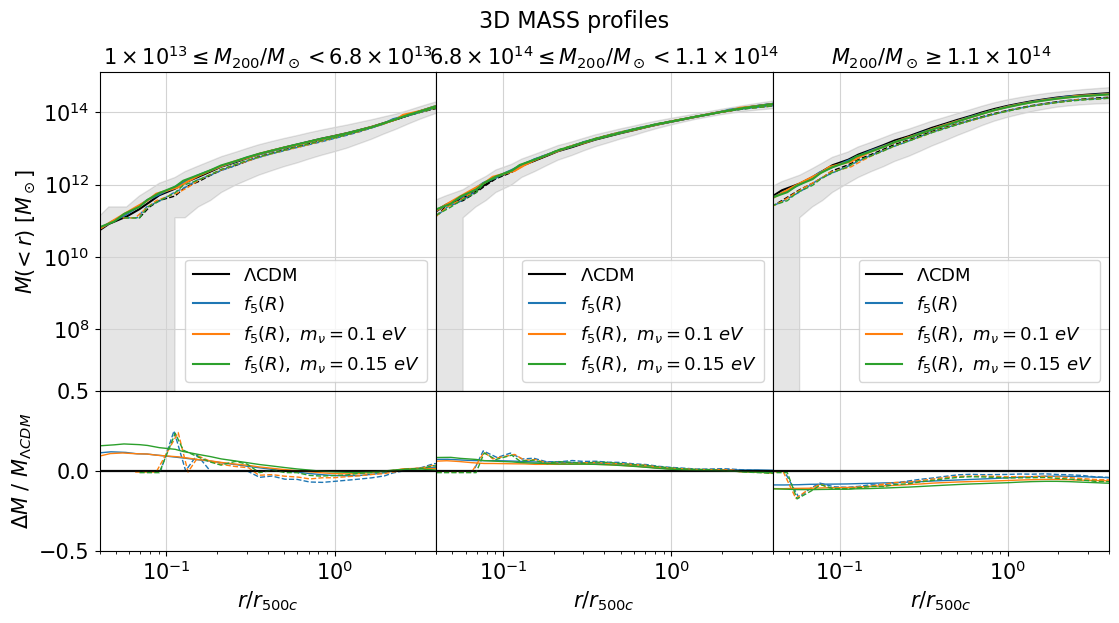

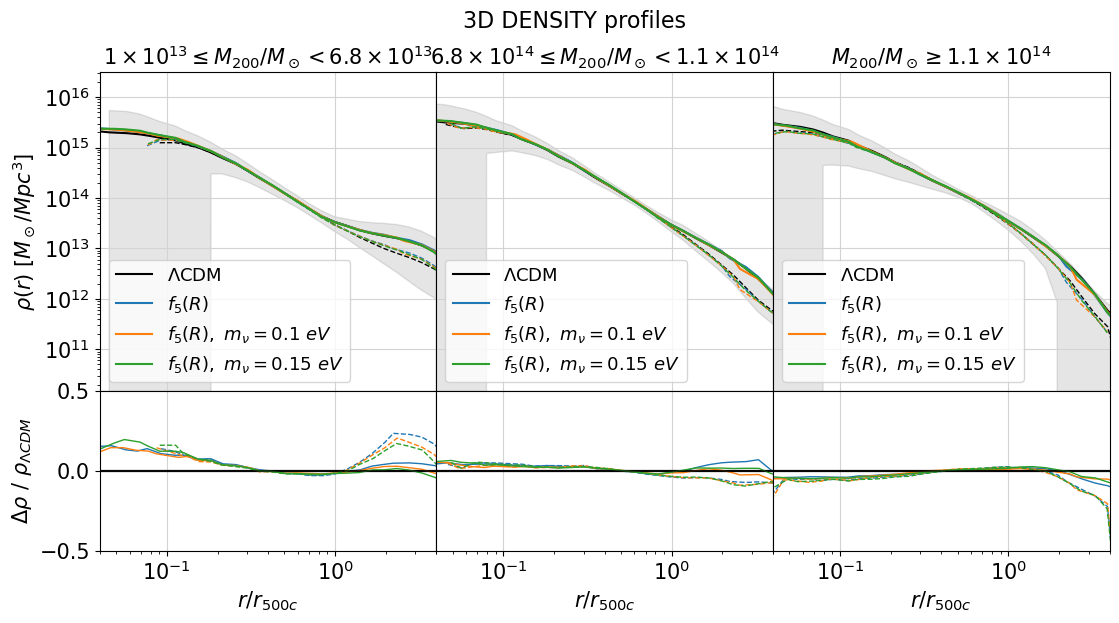

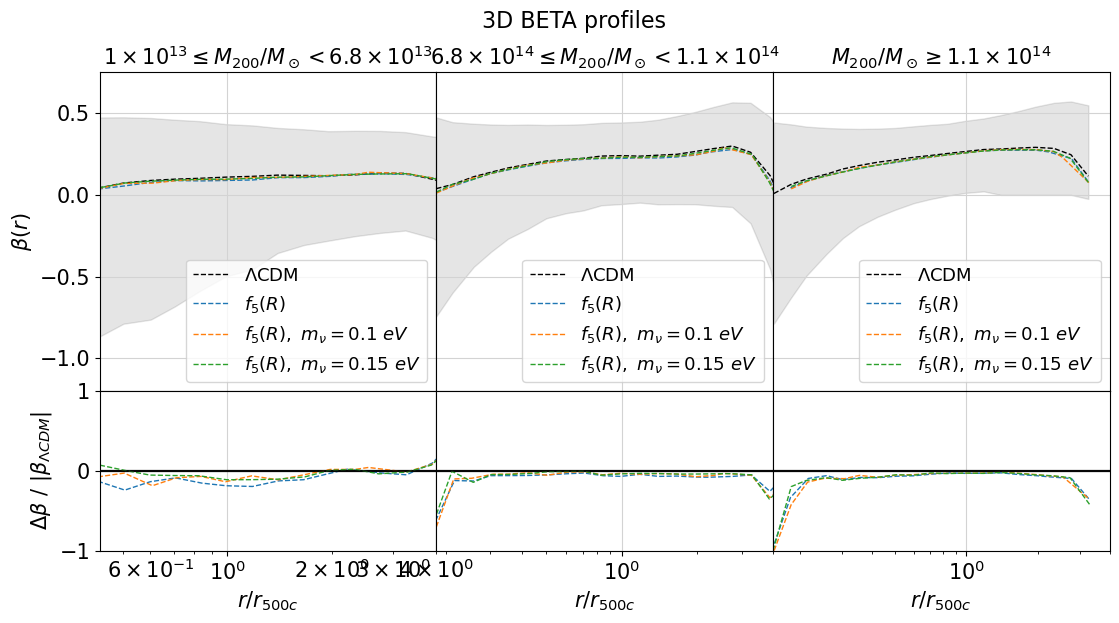

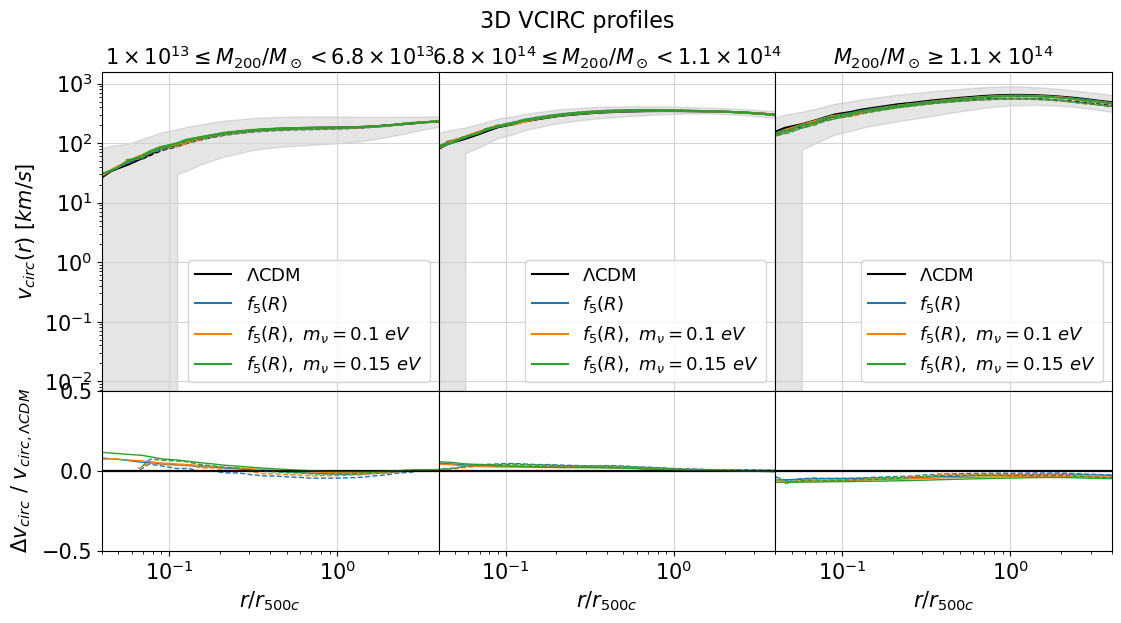

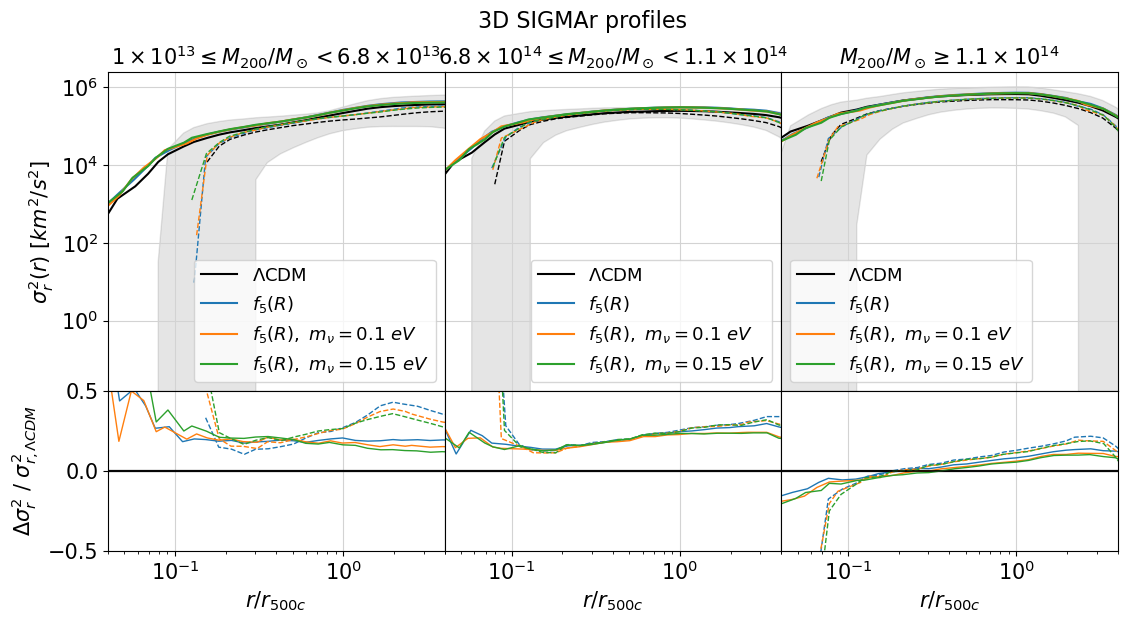

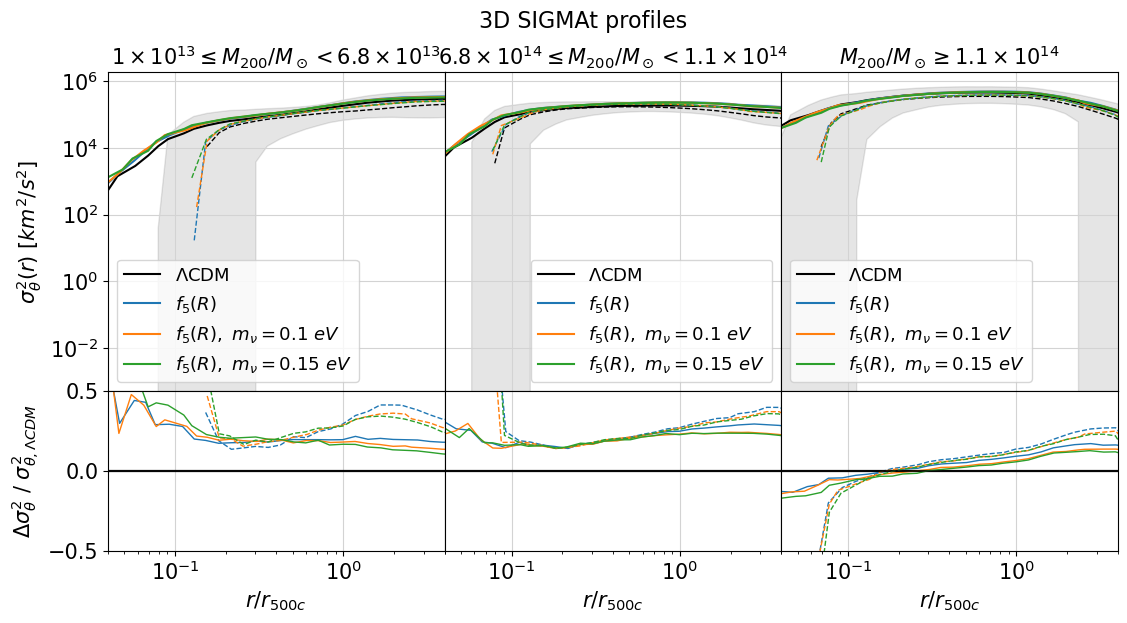

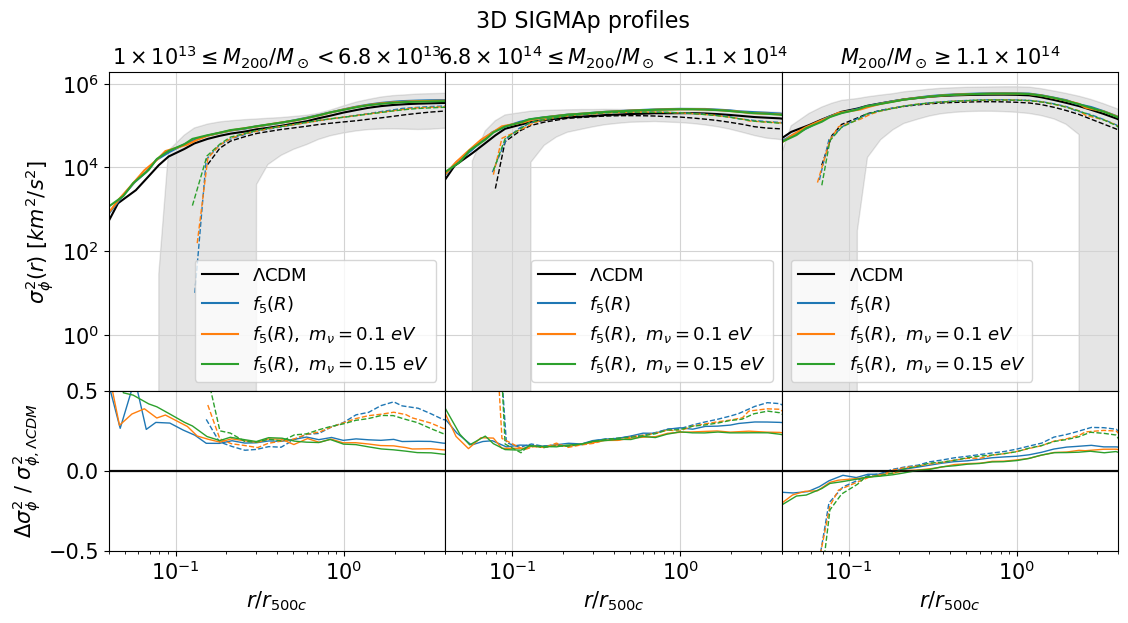

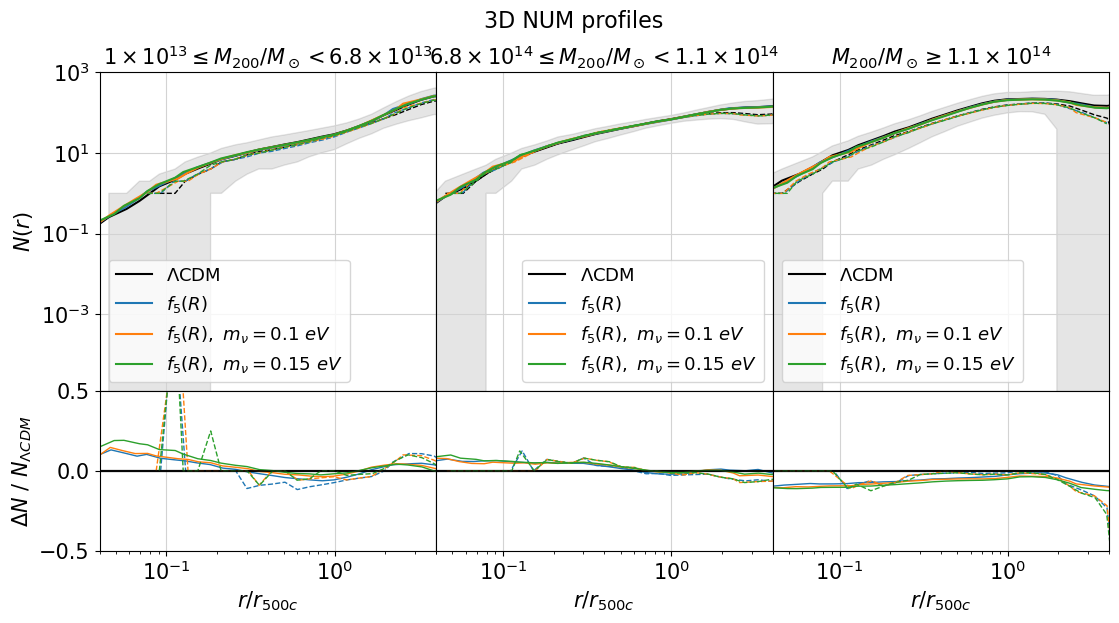

In [29]:
#Quantities and labels used in plotting, used for both the stacked profiles and relative differences panels
plot_quantities = ["MASS", "DENSITY", "BETA", "VCIRC", "SIGMAr", "SIGMAt", "SIGMAp", "NUM"]
quantity_labels = ["$M(\!< r)\ [M_\odot]$", "$\\rho(r)\ [M_\odot/Mpc^3]$", "$\\beta(r)$", "$v_{circ}(r)\ [km/s]$",
                  "$\sigma^2_r(r)\ [km^2/s^2]$", "$\sigma^2_\\theta (r)\ [km^2/s^2]$", "$\sigma^2_\phi (r)\ [km^2/s^2]$", "$N(r)$"]

quantity_labels_diff = ["$\Delta M\ /\ M_{\Lambda CDM}$", "$\Delta \\rho\ /\ \\rho_{\Lambda CDM}$", "$\Delta \\beta\ /\ | \\beta_{\Lambda CDM} |$",
                       "$\Delta v_{circ}\ /\ v_{circ, \Lambda CDM}$", "$\Delta \sigma^2_r\ /\ \sigma^2_{r, \Lambda CDM}$",
                       "$\Delta \sigma^2_\\theta\ /\ \sigma^2_{\\theta, \Lambda CDM}$", "$\Delta \sigma^2_\\phi\ /\ \sigma^2_{\\phi, \Lambda CDM}$",
                       "$\Delta N\ /\ N_{\Lambda CDM}$"]

#Plot the mean and median mass, density and beta profiles for every model and mass interval
for quantity, q_label, q_label_diff in zip(plot_quantities, quantity_labels, quantity_labels_diff):
    #Loop over the simulation types and assign the same color to the mean and median profiles of the same simulation
    for b, sim_batch in zip(["DMO", "Mag"], simulation_batches):
        #Compute the stacked profiles for every mass interval and draw them on the corresponding axis
        fig, ax = plt.subplots(2, len(mass_intervals), figsize=(11, 6), sharey="row", sharex="col", gridspec_kw={"height_ratios": [2, 1]})
    
        for sim_type in sim_batch:
            R = halo_profiles_3D[sim_type]["R"][0]    #In units of r500
            M200 = fit_pars_3D[sim_type]["NFW"]["MASS"]["M200"]    #In Msun
            
            for k in range(len(mass_intervals)):
                quantity_profile = halo_profiles_3D[sim_type][quantity]
        
                #Divide the halos in mass intervals based on their M200 NFW from the mass fits
                if k != len(mass_intervals) - 1:
                    idx = np.where(np.logical_and(M200 >= mass_intervals[k], M200 < mass_intervals[k + 1]))[0]
        
                else:
                    idx = np.where(M200 >= mass_intervals[k])[0]
    
                
                if len(mass_intervals) > 1:
                    ax0 = ax[0, k]
                    ax1 = ax[1, k]
    
                else:
                    ax0 = ax[0]
                    ax1 = ax[1]
    
                #Compute mean and median profiles
                mean_profile = np.mean(quantity_profile[idx, :], axis=0)
                median_profile = np.median(quantity_profile[idx, :], axis=0)
    
                profile_low, profile_high = np.quantile(quantity_profile[idx, :], [0.16, 0.84], axis=0)
    
                M200_lcdm = fit_pars_3D[sim_batch[0]]["NFW"]["MASS"]["M200"]
                
                if k != len(mass_intervals) - 1:
                    idx_lcdm = np.where(np.logical_and(M200_lcdm >= mass_intervals[k], M200_lcdm < mass_intervals[k + 1]))[0]
        
                else:
                    idx_lcdm = np.where(M200_lcdm >= mass_intervals[k])[0]
        
                lcdm_profile = halo_profiles_3D[sim_batch[0]][quantity][idx_lcdm, :]
                mean_lcdm = np.mean(lcdm_profile, axis=0)
                median_lcdm = np.median(lcdm_profile, axis=0)
            
                #Plot the mean and median profiles, with different limits for BETA
                with np.errstate(divide="ignore", invalid="ignore"):
                    if quantity == "BETA":   
                        if sim_type == sim_batch[0]:
                            ax0.fill_between(R[median_profile != 0], profile_low[median_profile != 0], profile_high[median_profile != 0], 
                                                                                                                     color="black", alpha=0.1)
                            ax0.plot(R[median_profile != 0], median_profile[median_profile != 0], color="black", linestyle="--", 
                                                                                                                 label=model_names[sim_type], lw=1.)
                        
                        else:
                            line, = ax0.plot(R[median_profile != 0], median_profile[median_profile != 0], linestyle="--", 
                                             label=model_names[sim_type], lw=1.)
    
                            if len(simulation_type) > 1:
                                mean_diff = (mean_profile - np.mean(lcdm_profile, axis=0)) / np.abs(np.mean(lcdm_profile, axis=0))
                                median_diff = (median_profile - np.median(lcdm_profile, axis=0)) / np.abs(np.median(lcdm_profile, axis=0))
                                ax1.plot(R[median_lcdm != 0], median_diff[median_lcdm != 0], linestyle="--", lw=1., color=line.get_color())
                            
                        ax0.set_xlim(R[median_lcdm != 0].min(), 4.)
                        ax0.set_ylim(-1.2, 0.75)
                        ax0.set_xscale("log")
                        ax1.set_ylim(-1., 1.)
            
                    else:
                        if sim_type == sim_batch[0]:
                            ax0.fill_between(R, profile_low, profile_high, color="black", alpha=0.1)  
                            line, = ax0.loglog(R, mean_profile, color="black", label=model_names[sim_type])
                            ax0.loglog(R[median_profile > 0], median_profile[median_profile > 0], color="black", linestyle="--", lw=1.)
    
                        else:
                            line, = ax0.loglog(R, mean_profile, label=model_names[sim_type])
                            ax0.loglog(R[median_profile > 0], median_profile[median_profile > 0], color=line.get_color(), linestyle="--", lw=1.)
    
                            if len(sim_batch) > 1:
                                mean_diff = (mean_profile - np.mean(lcdm_profile, axis=0)) / np.mean(lcdm_profile, axis=0)
                                median_diff = (median_profile - np.median(lcdm_profile, axis=0)) / np.median(lcdm_profile, axis=0)
                                ax1.plot(R, mean_diff, linestyle="-", lw=1., color=line.get_color())
                                ax1.plot(R[median_lcdm != 0], median_diff[median_lcdm != 0], linestyle="--", lw=1., color=line.get_color())
                        
                        ax0.set_xlim(0.04, 4.)
                        ax1.set_ylim(-0.5, 0.5)
        
                ax0.tick_params(axis="y", which="both", labelsize=15)
                ax1.tick_params(axis="y", which="both", labelsize=15)
                
                if k != 0:
                    ax0.tick_params(axis="y", which="both", left=False, labelleft=False)
                    ax1.tick_params(axis="y", which="both", left=False, labelleft=False)
    
                ax0.set_title(plot_titles[k], size=15)
                ax0.legend(prop={"size": 13})
                ax0.grid(color="lightgrey")
    
                ax1.set_xlabel("$r/r_{500c}$", size=15)
                ax1.tick_params(axis="x", which="both", labelsize=15)
                ax1.axhline(0, linestyle="-", color="black", alpha=0.6)
                ax1.grid(color="lightgrey")
    
        fig.tight_layout()
        fig.subplots_adjust(hspace=0., wspace=0.)
        fig.suptitle("3D " + quantity + " profiles", size=16, y=1.03)
    
        ax[0, 0].set_ylabel(q_label, size=15)
        ax[1, 0].set_ylabel(q_label_diff, size=15)
    
        if save_plots:
            fig.savefig(fig_path + "/" + quantity + "_PROFILES_3D_z029" + ".png", dpi=300, bbox_inches='tight')

#### Stacked 2D profiles

In [99]:
import astropy.units as u 
import astropy.cosmology.units as cu
from astropy.cosmology import Planck18 as cosmo

In [115]:
c = 3e5 * u.km / u.s
G = G_mpc * u.Msun**-1 * u.Mpc * u.km**2 * u.s**-2
n_g = 26 * u.arcmin**-2

z = sim_props["LCDM"]["COSM_PARS"][-1] * cu.redshift
Dls_Ds = 3.60 * u.arcmin**-1 / np.sqrt(n_g)

Dl = z.to(u.Mpc, cu.redshift_distance(cosmo, kind="comoving")) / (1 + z.to(u.dimensionless_unscaled))

sigma_crit = c**2 / (4 * np.pi * G) / Dls_Ds / Dl

In [107]:
from colossus.cosmology import cosmology
from colossus.halo import profile_nfw

h, Om, Ol, z = sim_props["LCDM"]["COSM_PARS"]
H2z = (h * 100)**2 * (Om * (1 + z)**3 + Ol)
rho_c = 3 * H2z / (8 * np.pi * G_mpc)

cpars = {'flat': True, 'H0': h * 100, 'Om0': Om, 'Ob0': 0.049, 'sigma8': 0.81, 'ns': 0.95}
cosmology.setCosmology("myCosmo", **cpars)

ng = 26 * 0.37**-2

error = []
r_lim_r500 = []

R = halo_profiles_2D["LCDM"]["x"]["R"][0]

for k, c, M in zip(np.arange(0, 3, dtype=int), [10., 3.5, 1.5], [4.4e13, 8.6e13, 2e14]):
    c200 = c
    M200 = M
    r200 = (M200 / (100 * H2z / G_mpc))**(1/3)
    rs = r200 / c200
    
    # profile_r5 = lambda r: HaloProfile(np.log10(r), np.log10(r200), np.log10(rs), 0., cosm_parameters["LCDM"], "NFW", "MASS") - 4/3 * np.pi * r**3 * 500 * rho_c
    # r500 = brentq(profile_r5, 1e-3, 100.)

    pnfw = profile_nfw.NFWProfile(M=M200, c=c200, mdef="vir", z=z)
    # dsigma_nfw = pnfw.deltaSigma(bins * 1e3 * h) * h**2 * 1e6
    r500 = pnfw.RDelta(z=z, mdef="500c") * 1e-3 / h
    
    r_lim = 0.3
    r_lim_r5 = r_lim / r500
    rad = np.logspace(np.log10(r_lim), np.log10(5 * r500), np.sum(R > r_lim_r5) + 1)
    rad_r5 = rad / r500
    bins = 10**(np.log10(rad[:-1]) + np.diff(np.log10(rad)) / 2)
    bins_r5 = bins / r500
    
    error.append(np.array(sigma_crit * 0.3 / np.sqrt(ng * np.pi * (rad[1:]**2 - rad[:-1]**2))))
    r_lim_r500.append(r_lim_r5)
    
error

[array([1.16421522e+14, 9.80701850e+13, 8.26115397e+13, 6.95896158e+13,
        5.86203168e+13, 4.93800907e+13, 4.15963866e+13, 3.50396152e+13,
        2.95163771e+13, 2.48637581e+13, 2.09445240e+13, 1.76430724e+13]),
 array([1.17431492e+14, 9.91678862e+13, 8.37447392e+13, 7.07202867e+13,
        5.97214702e+13, 5.04332515e+13, 4.25895888e+13, 3.59658166e+13,
        3.03722107e+13, 2.56485538e+13, 2.16595465e+13, 1.82909321e+13,
        1.54462236e+13]),
 array([1.17747819e+14, 9.95116318e+13, 8.40997731e+13, 7.10748252e+13,
        6.00671154e+13, 5.07642241e+13, 4.29021175e+13, 3.62576543e+13,
        3.06422520e+13, 2.58965349e+13, 2.18858104e+13, 1.84962467e+13,
        1.56316414e+13, 1.32106918e+13])]

In [117]:
sigma_crit

<Quantity 1.81926209e+15 solMass / Mpc2>

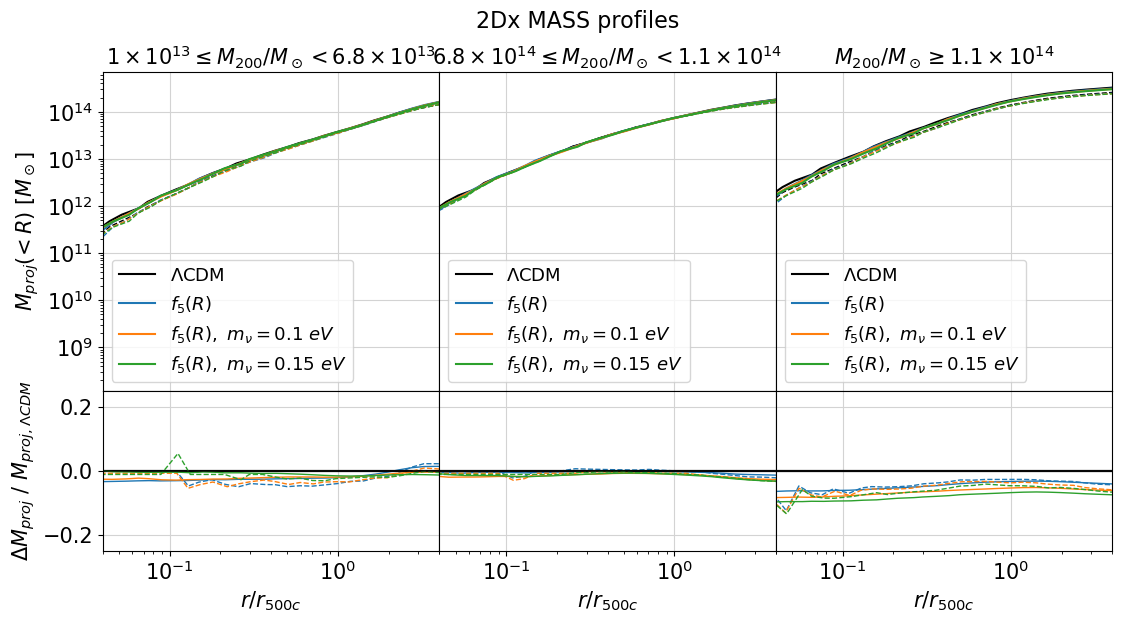

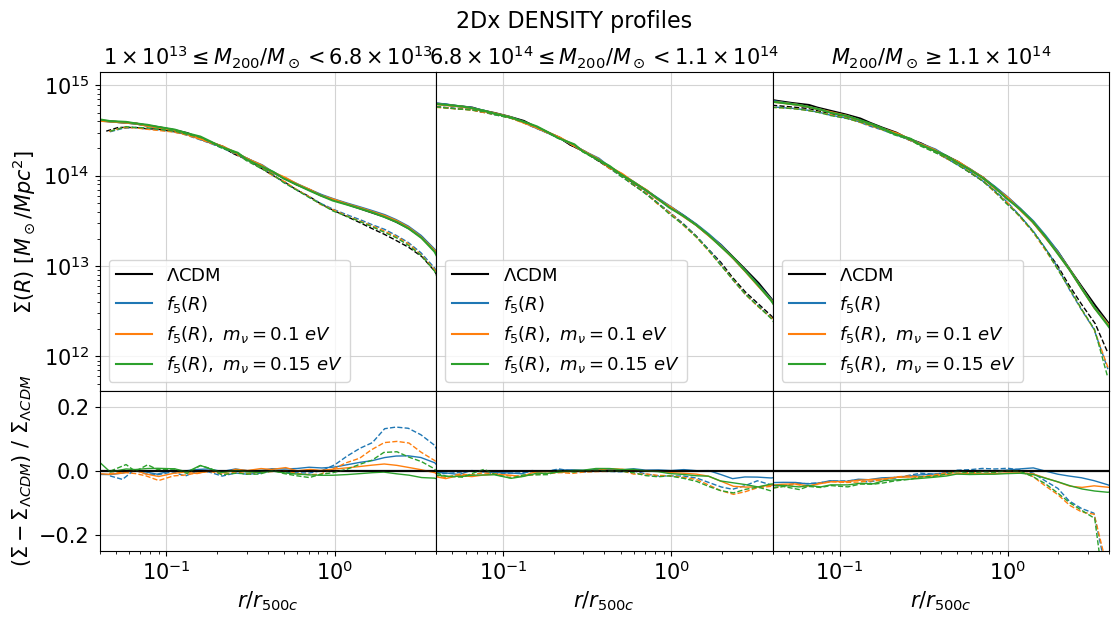

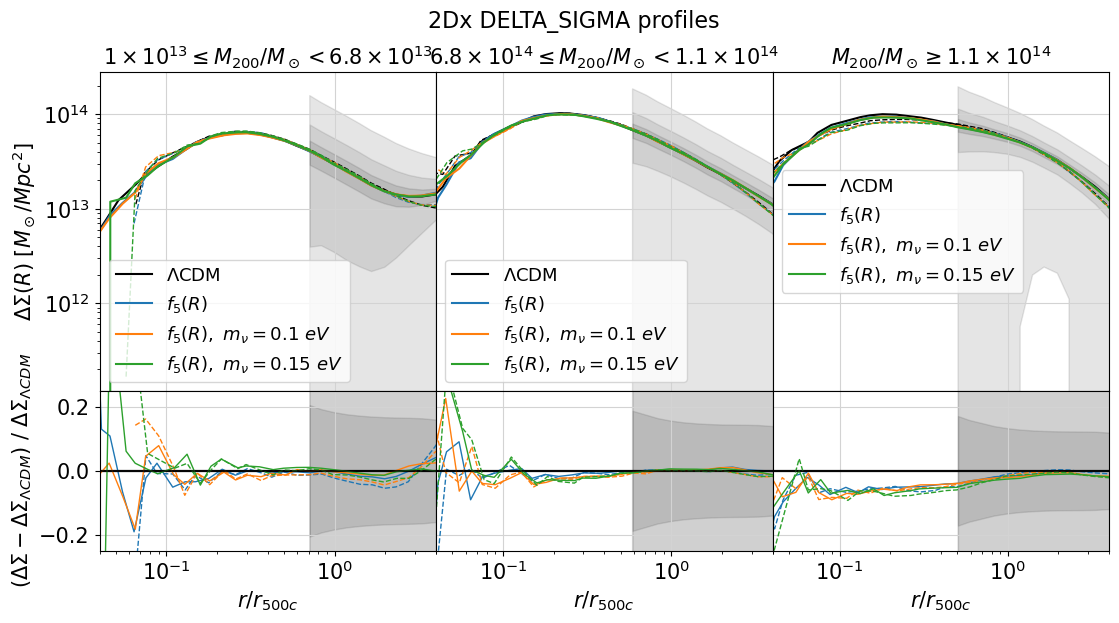

In [121]:
#Quantities and labels used in plotting, used for both the stacked profiles and relative differences panels
plot_quantities = ["MASS", "DENSITY", "DELTA_SIGMA"]
quantity_labels = ["$M_{proj}(\!< R)\ [M_\odot]$", "$\Sigma(R)\ [M_\odot/Mpc^2]$", "$\Delta \Sigma(R)\ [M_\odot/Mpc^2]$"]

quantity_labels_diff = ["$\Delta M_{proj}\ /\ M_{proj, \Lambda CDM}$", "$(\Sigma - \Sigma_{\Lambda CDM})\ /\ \Sigma_{\Lambda CDM}$", 
                        "$(\Delta \Sigma - \Delta \Sigma_{\Lambda CDM})\ /\ \Delta \Sigma_{\Lambda CDM}$"]

#Plot the mean and median mass, density and beta profiles for every model and mass interval
for dim in projections:
    for quantity, q_label, q_label_diff in zip(plot_quantities, quantity_labels, quantity_labels_diff):        
        #Loop over the simulation types and assign the same color to the mean and median profiles of the same simulation
        for b, sim_batch in zip(["DMO", "Mag"], simulation_batches):
            #Compute the stacked profiles for every mass interval and draw them on the corresponding axis
            fig, ax = plt.subplots(2, len(mass_intervals), figsize=(11, 6), sharey="row", sharex="col", gridspec_kw={"height_ratios": [2, 1]})
        
            for sim_type in sim_batch:
                R = halo_profiles_2D[sim_type][dim]["R"][0]    #In units of r500
                M200 = fit_pars_3D[sim_type]["NFW"]["MASS"]["M200"]
                
                for k in range(len(mass_intervals)):
                    quantity_profile = halo_profiles_2D[sim_type][dim][quantity]
            
                    #Divide the halos in mass intervals based on their M200 NFW from the mass fits
                    if k != len(mass_intervals) - 1:
                        idx = np.where(np.logical_and(M200 >= mass_intervals[k], M200 < mass_intervals[k + 1]))[0]
            
                    else:
                        idx = np.where(M200 >= mass_intervals[k])[0]
        
                    
                    if len(mass_intervals) > 1:
                        ax0 = ax[0, k]
                        ax1 = ax[1, k]
        
                    else:
                        ax0 = ax[0]
                        ax1 = ax[1]
        
                    #Compute mean and median profiles
                    mean_profile = np.mean(quantity_profile[idx, :], axis=0)
                    median_profile = np.median(quantity_profile[idx, :], axis=0)
        
                    profile_low, profile_high = np.quantile(quantity_profile[idx, :], [0.16, 0.84], axis=0)
        
                    M200_lcdm = fit_pars_3D[sim_batch[0]]["NFW"]["MASS"]["M200"]
                    
                    if k != len(mass_intervals) - 1:
                        idx_lcdm = np.where(np.logical_and(M200_lcdm >= mass_intervals[k], M200_lcdm < mass_intervals[k + 1]))[0]
            
                    else:
                        idx_lcdm = np.where(M200_lcdm >= mass_intervals[k])[0]
            
                    lcdm_profile = halo_profiles_2D[sim_batch[0]][dim][quantity][idx_lcdm, :]
                    mean_lcdm = np.mean(lcdm_profile, axis=0)
                    median_lcdm = np.median(lcdm_profile, axis=0)
                
                    #Plot the mean and median profiles, with different limits for BETA
                    with np.errstate(divide="ignore", invalid="ignore"):
                        if sim_type == sim_batch[0]:
                            # ax0.fill_between(R, profile_low, profile_high, color="black", alpha=0.1)  
                            line, = ax0.loglog(R, mean_profile, color="black", label=model_names[sim_type])
                            ax0.loglog(R[median_profile > 0], median_profile[median_profile > 0], color="black", linestyle="--", lw=1.)

                            if quantity == "DELTA_SIGMA":
                                err_bars = error[k]
                                cond_r = (R > r_lim_r500[k])
                                ax0.fill_between(R[cond_r], np.mean(quantity_profile[idx, :], axis=0)[cond_r] - err_bars, np.mean(quantity_profile[idx, :], axis=0)[cond_r] + err_bars, color="black", alpha=0.1)
                                ax0.fill_between(R[cond_r], np.mean(quantity_profile[idx, :], axis=0)[cond_r] - err_bars/np.sqrt(10), np.mean(quantity_profile[idx, :], axis=0)[cond_r] + err_bars/np.sqrt(10), color="black", alpha=0.09)
                                ax0.fill_between(R[cond_r], np.mean(quantity_profile[idx, :], axis=0)[cond_r] - err_bars/np.sqrt(100), np.mean(quantity_profile[idx, :], axis=0)[cond_r] + err_bars/np.sqrt(100), color="black", alpha=0.1)
                                
                                ax1.fill_between(R[cond_r], (-err_bars) / np.mean(quantity_profile, axis=0)[cond_r], 
                                 (err_bars) / np.mean(quantity_profile, axis=0)[cond_r], color="black", alpha=0.1)
                
                                ax1.fill_between(R[cond_r], (-err_bars/np.sqrt(10)) / np.mean(quantity_profile, axis=0)[cond_r], 
                                 (err_bars/np.sqrt(10)) / np.mean(quantity_profile, axis=0)[cond_r], color="black", alpha=0.09)
                                
                                ax1.fill_between(R[cond_r], (-err_bars/np.sqrt(100)) / np.mean(quantity_profile, axis=0)[cond_r], 
                                 (err_bars/np.sqrt(100)) / np.mean(quantity_profile, axis=0)[cond_r], color="black", alpha=0.1)
        
                        else:
                            line, = ax0.loglog(R, mean_profile, label=model_names[sim_type])
                            ax0.loglog(R[median_profile > 0], median_profile[median_profile > 0], color=line.get_color(), linestyle="--", lw=1.)
        
                            if len(sim_batch) > 1:
                                mean_diff = (mean_profile - np.mean(lcdm_profile, axis=0)) / np.mean(lcdm_profile, axis=0)
                                median_diff = (median_profile - np.median(lcdm_profile, axis=0)) / np.median(lcdm_profile, axis=0)
                                ax1.plot(R, mean_diff, linestyle="-", lw=1., color=line.get_color())
                                ax1.plot(R[median_lcdm != 0], median_diff[median_lcdm != 0], linestyle="--", lw=1., color=line.get_color())
                            
                        ax0.set_xlim(0.04, 4.)
                        ax1.set_ylim(-0.25, 0.25)
            
                    ax0.tick_params(axis="y", which="both", labelsize=15)
                    ax1.tick_params(axis="y", which="both", labelsize=15)
                    
                    if k != 0:
                        ax0.tick_params(axis="y", which="both", left=False, labelleft=False)
                        ax1.tick_params(axis="y", which="both", left=False, labelleft=False)
        
                    ax0.set_title(plot_titles[k], size=15)
                    ax0.legend(prop={"size": 13})
                    ax0.grid(color="lightgrey")
        
                    ax1.set_xlabel("$r/r_{500c}$", size=15)
                    ax1.tick_params(axis="x", which="both", labelsize=15)
                    ax1.axhline(0, linestyle="-", color="black", alpha=0.6)
                    ax1.grid(color="lightgrey")
        
            fig.tight_layout()
            fig.subplots_adjust(hspace=0., wspace=0.)
            fig.suptitle("2D" + dim + " " + quantity + " profiles", size=16, y=1.03)
        
            ax[0, 0].set_ylabel(q_label, size=15)
            ax[1, 0].set_ylabel(q_label_diff, size=15)
        
            if save_plots:
                fig.savefig(fig_path + "/" + quantity + "_PROFILES_2D" + dim + "_z05" + ".png", dpi=300, bbox_inches='tight')

#### Concentration-mass relation

Show the median concentration-mass relation with the relative $68\%$ scatter, computed in a set number of $\log{M_{200}}$ bins. A condition can be applied on the samples, such as only selecting halos with $\chi^2_{dof} < 2$.

In [69]:
mass_0 = np.log10(fit_pars_3D[simulation_type[0]]["NFW"]["MASS"]["M200"])

#-------------------------------------#
cond_0 = (mass_0 < 15) & (10**mass_0 > 5e13)
#-------------------------------------#

#Set the mass bins edges as quantiles of the LCDM M200 distribution, as to guarantee a similar number of halos in each bin 
mass_bins = np.quantile(mass_0[cond_0], np.linspace(0., 1., 5))
bin_centers = mass_bins[:-1] + np.diff(mass_bins) / 2

print("Log virial mass bins:")
for m in mass_bins:
    print(f"{m:.2f}")

Log virial mass bins:
13.70
13.92
14.10
14.34
15.00


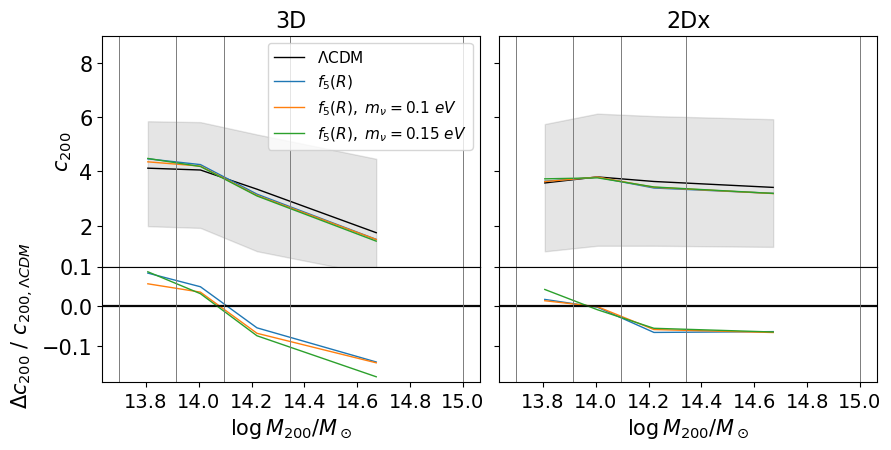

In [73]:
c200_med = {sim_type: np.empty(len(mass_bins) - 1) for sim_type in simulation_type}
c200_up = {sim_type: np.empty(len(mass_bins) - 1) for sim_type in simulation_type}
c200_down = {sim_type: np.empty(len(mass_bins) - 1) for sim_type in simulation_type}

c200_med_2D = {sim_type: np.empty(len(mass_bins) - 1) for sim_type in simulation_type}
c200_up_2D = {sim_type: np.empty(len(mass_bins) - 1) for sim_type in simulation_type}
c200_down_2D = {sim_type: np.empty(len(mass_bins) - 1) for sim_type in simulation_type}

for b, sim_batch in zip(["DMO", "Mag"], simulation_batches):
    fig, ax = plt.subplots(2, len(projections) + 1, figsize=(5 * (len(projections) + 1), 4.5), 
                       sharex="col", sharey="row", gridspec_kw={"height_ratios": [2, 1]})

    for i, sim_type in enumerate(sim_batch):    
        r200 = 10**fit_pars_3D[sim_type]["NFW"]["MASS"]["r200"]
        rs = 10**fit_pars_3D[sim_type]["NFW"]["MASS"]["rs"]
        M200 = fit_pars_3D[sim_type]["NFW"]["MASS"]["M200"]
        chi2 = fit_pars_3D[sim_type]["NFW"]["MASS"]["chi2"]
    
        #---------------------------------#
        cond = (chi2 < np.inf)
        #---------------------------------#
        
        c200 = (r200 / rs)[cond]
        lM200 = np.log10(M200[cond])
    
        #Divide the halos in mass intervals based on their M200 NFW from the mass fits    
        for k in range(len(mass_bins) - 1):
            idx = np.where(np.logical_and(lM200 >= mass_bins[k], lM200 < mass_bins[k + 1]))[0]
            
            c200_med[sim_type][k] = np.median(c200[idx])
            c200_down[sim_type][k], c200_up[sim_type][k] = np.quantile(c200[idx], [0.16, 0.84])
    
        #3D
        if sim_type == sim_batch[0]:
            ax[0, 0].fill_between(bin_centers, c200_down[sim_type], c200_up[sim_type], color="black", alpha=0.1)
            ax[0, 0].plot(bin_centers, c200_med[sim_type], label=model_names[sim_type], lw=1., c="black")
    
        else:
            line, = ax[0, 0].plot(bin_centers, c200_med[sim_type], label=model_names[sim_type], lw=1.)
    
            med_diff = (c200_med[sim_type] - c200_med[sim_batch[0]]) / c200_med[sim_batch[0]]
            ax[1, 0].plot(bin_centers, med_diff, lw=1., c=line.get_color())
    
        ax[0, 0].set_title("3D", size=16)
        ax[0, 0].set_ylabel("$c_{200}$", size=15)
        ax[0, 0].legend(prop={"size": 11})
        ax[0, 0].tick_params(axis="y", which="both", labelsize=15)
    
        ax[1, 0].axhline(0., ls="-", c="black", alpha=0.6)
        ax[1, 0].set_xlabel("$\log{M_{200} / M_\odot}$", size=15)
        ax[1, 0].set_ylabel("$\Delta c_{200}\ /\ c_{200, \Lambda CDM}$", size=15)
        ax[1, 0].tick_params(axis="y", which="both", labelsize=15)
        ax[1, 0].tick_params(axis="x", which="both", labelsize=14)
    
        for m in mass_bins:
            ax[0, 0].axvline(m, ls="-", lw=0.5, color="grey")
            ax[1, 0].axvline(m, ls="-", lw=0.5, color="grey")
    
        #2D
        for d, dim in enumerate(projections):
            r200_2D = 10**fit_pars_2D[sim_type][dim]["NFW"]["MASS"]["r200"]
            rs_2D = 10**fit_pars_2D[sim_type][dim]["NFW"]["MASS"]["rs"]
            M200_2D = fit_pars_2D[sim_type][dim]["NFW"]["MASS"]["M200"]
            chi2_2D = fit_pars_2D[sim_type][dim]["NFW"]["MASS"]["chi2"]
    
            #------------------------------------------#
            cond_2D = (chi2_2D < np.inf)
            #------------------------------------------#
            
            c200_2D = (r200_2D / rs_2D)[cond_2D]
            lM200_2D = np.log10(M200_2D[cond_2D])
    
            for k in range(len(mass_bins) - 1):
                idx_2D = np.where(np.logical_and(lM200_2D >= mass_bins[k], lM200_2D < mass_bins[k + 1]))[0]
                    
                c200_med_2D[sim_type][k] = np.median(c200_2D[idx_2D])
                c200_down_2D[sim_type][k], c200_up_2D[sim_type][k] = np.quantile(c200_2D[idx_2D], [0.16, 0.84])
            
            if sim_type == sim_batch[0]:
                ax[0, d + 1].fill_between(bin_centers, c200_down_2D[sim_type], c200_up_2D[sim_type], color="black", alpha=0.1)
                ax[0, d + 1].plot(bin_centers, c200_med_2D[sim_type], label=model_names[sim_type], lw=1., c="black")
        
            else:
                line_2D, = ax[0, d + 1].plot(bin_centers, c200_med_2D[sim_type], label=model_names[sim_type], lw=1.)
                
                med_diff_2D = (c200_med_2D[sim_type] - c200_med_2D[sim_batch[0]]) / c200_med_2D[sim_batch[0]]
                ax[1, d + 1].plot(bin_centers, med_diff_2D, lw=1., c=line_2D.get_color())
        
            ax[0, d + 1].set_title("2D" + dim, size=16)
            ax[0, d + 1].set_ylim(0.5, 9)
            ax[0, d + 1].tick_params(axis="x", which="both", labelbottom=False)
            ax[0, d + 1].tick_params(axis="y", which="both", labelleft=False)
            
            ax[1, d + 1].tick_params(axis="y", which="both", labelleft=False)
            ax[1, d + 1].tick_params(axis="x", which="both", labelsize=14)
        
            ax[1, d + 1].axhline(0., ls="-", c="black", alpha=0.6)
            ax[1, d + 1].set_xlabel("$\log{M_{200} / M_\odot}$", size=15)
    
            for m in mass_bins:
                ax[0, d + 1].axvline(m, ls="-", lw=0.5, color="grey")
                ax[1, d + 1].axvline(m, ls="-", lw=0.5, color="grey")
    
        fig.subplots_adjust(hspace=0., wspace=0.05)
    
    if save_plots:
        fig.savefig(fig_path + "/cM_relation_diff_z029" + ".png", dpi=300, bbox_inches='tight')

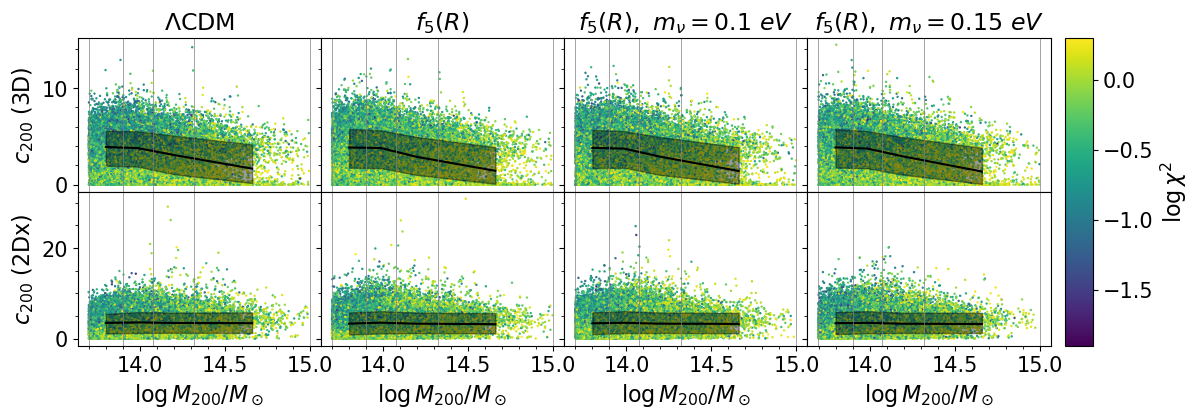

In [100]:
fig_c, ax_c = plt.subplots(len(projections) + 1, len(simulation_type), figsize=(14, 2 * (len(projections) + 1)), sharex="col", sharey="row")

for i, sim_type in enumerate(simulation_type):
    for quantity in ["MASS"]:
        r200 = 10**fit_pars_3D[sim_type]["NFW"]["MASS"]["r200"]
        rs = 10**fit_pars_3D[sim_type]["NFW"]["MASS"]["rs"]
        M200 = fit_pars_3D[sim_type]["NFW"]["MASS"]["M200"]
        chi2 = fit_pars_3D[sim_type]["NFW"]["MASS"]["chi2"]
    
        #---------------------------------#
        cond = (chi2 < 2) & (M200 < 1e15) & (M200 > 5e13)
        #---------------------------------#
        
        c200 = (r200 / rs)[cond]
        lM200 = np.log10(M200[cond])    

        ax_c[0, i].tick_params(axis="x", labelsize=15)
        ax_c[0, i].tick_params(axis="y", labelsize=15)
        ax_c[0, i].minorticks_on()
            
        scatter = ax_c[0, i].scatter(lM200, c200, c=np.log10(chi2[cond]), cmap='viridis', 
                                  clim=(np.min(np.log10(chi2[cond])), np.max(np.log10(chi2[cond]))), s=0.5, rasterized=True)

        ax_c[0, i].plot(bin_centers, c200_med[sim_type], color="black")

        #Credible region
        ax_c[0, i].fill_between(bin_centers, c200_down[sim_type], c200_up[sim_type], alpha=0.4, color="black")
        
        # ax_c[0, i].set_xlabel(r'$\log{M_{200}/M$_\odot}$', size=14)
        ax_c[0, 0].set_ylabel(r'$c_{200}$ (3D)', size=16)
        ax_c[0, i].tick_params(axis="x", which="both", bottom=False, labelbottom=False, labelsize=15)
        
        if i != 0:
            ax_c[0, i].tick_params(axis="y", which="both", labelleft=False)
            
        ax_c[0, i].set_title(model_names[sim_type], size=17)

        for m in mass_bins:
            ax_c[0, i].axvline(m, ls="-", lw=0.5, color="grey")
        
        #############################################################################
        
        #2D concentration-mass relation
        for d, dim in enumerate(projections):
            r200_2D = 10**fit_pars_2D[sim_type][dim]["NFW"]["MASS"]["r200"]
            rs_2D = 10**fit_pars_2D[sim_type][dim]["NFW"]["MASS"]["rs"]
            M200_2D = fit_pars_2D[sim_type][dim]["NFW"]["MASS"]["M200"]
            chi2_2D = fit_pars_2D[sim_type][dim]["NFW"]["MASS"]["chi2"]
        
            #------------------------------------------#
            cond_2D = (chi2_2D < 2.) & (M200_2D > 5e13) & (M200_2D < 1e15)
            #------------------------------------------#
            
            c200_2D = (r200_2D / rs_2D)[cond_2D]
            lM200_2D = np.log10(M200_2D[cond_2D])
    
            ax_c[d + 1, i].tick_params(axis="x", labelsize=15)
            ax_c[d + 1, i].tick_params(axis="y", labelsize=15)
            ax_c[d + 1, i].minorticks_on()
            
            scatter_2D = ax_c[d + 1, i].scatter(lM200_2D, c200_2D, c=np.log10(chi2_2D[cond_2D]), cmap='viridis', 
                                         clim=(np.min(np.log10(chi2_2D[cond_2D])), np.max(np.log10(chi2_2D[cond_2D]))), s=0.5, rasterized=True)
            ax_c[d + 1, i].plot(bin_centers, c200_med_2D[sim_type], color="black")
    
            #Credible region
            ax_c[d + 1, i].fill_between(bin_centers, c200_down_2D[sim_type], c200_up_2D[sim_type], alpha=0.4, color="black")
            
            ax_c[d + 1, i].set_xlabel(r"$\log{M_{200}/M_\odot}$", size=16)
            ax_c[d + 1, 0].set_ylabel(r"$c_{200}$ (2D" + dim + ")", size=16)
            ax_c[d + 1, i].minorticks_on()

            for m in mass_bins:
                ax_c[d + 1, i].axvline(m, ls="-", lw=0.5, color="grey")


fig_c.subplots_adjust(right=0.82, hspace=0., wspace=0.)
cbar_ax = fig_c.add_axes([0.83, 0.11, 0.02, 0.77])
cbar = fig_c.colorbar(scatter_2D, cax=cbar_ax)
cbar.set_label(label="$\log{\chi^2}$", size=16)
cbar_ax.tick_params(labelsize=15)

if save_plots:
    fig_c.savefig(fig_path + "/cM_relation_median_z05.png", dpi=300, bbox_inches='tight')

#### Halo sparsities

In [ ]:
#Plot the sparsities s500 for each simulation
for sim_type in simulation_type:
    h, Om, Ol, z = sim_props_cut[sim_type]["COSM_PARS"]
    H2z = (h * 100)**2 * (Om * (1 + z)**3 + Ol)
    
    r200_sim = halo_props_cut[sim_type]["R200"]
    r500_sim = halo_props_cut[sim_type]["R500"]
    
    r200 = 10**fit_pars_3D[sim_type]["NFW"]["MASS"]["r200"]
    rs = 10**fit_pars_3D[sim_type]["NFW"]["MASS"]["rs"]
    M200_fit = fit_pars_3D[sim_type]["NFW"]["MASS"]["M200"]

    c200 = r200 / rs
    s500 = r200_sim**3 / r500_sim**3 * (200 / 500)
    M200_sim = 200 / (2 * G_mpc) * H2z * (r200_sim)**3

    #Condition on chi2
    chi2 = fit_pars_3D[sim_type]["NFW"]["MASS"]["chi2"]
    cond_s = (r200_sim > 0.)

    #Sparsity plots
    markersize = 0.1
    fig_s, ax_s = plt.subplots(1, 3, figsize=(7, 3), sharey="row", sharex="col", gridspec_kw={"width_ratios": [1, 1, 1.2]})
  
    scatter = ax_s[0].scatter(c200[cond_s], np.log10(s500[cond_s]), c=np.log10(chi2[cond_s]), s=markersize, rasterized=True)
    
    ax_s[0].set_xlabel("$c^{NFW}_{200}$", size=14)      
    ax_s[0].set_ylabel("$\log{s_{500}}$", size=14)
    ax_s[0].tick_params(axis="y", which="both", labelsize=13)
    ax_s[0].tick_params(axis="x", which="both", labelsize=13)
    ax_s[0].set_xscale("log")

    #MASS FIT
    scatter = ax_s[1].scatter(np.log10(M200_fit[cond_s]), np.log10(s500[cond_s]), c=np.log10(chi2[cond_s]), s=markersize, rasterized=True)

    ax_s[1].set_xlabel("$\log{M^{NFW}_{200}\ [M_\odot]}$", size=14)
    ax_s[1].tick_params(axis="y", which="both", left=False, labelleft=False)
    ax_s[1].tick_params(axis="x", which="both", labelsize=13)

    #MASS SIMULATION
    scatter = ax_s[2].scatter(np.log10(M200_sim[cond_s]), np.log10(s500[cond_s]), c=np.log10(chi2[cond_s]), s=markersize, rasterized=True)

    ax_s[2].set_xlabel("$\log{M^{SIM}_{200}\ [M_\odot]}$", size=14)
    cbar = plt.colorbar(scatter, location="right")
    cbar.set_label(r"Log $\chi^2$", fontsize=12)

    ax_s[2].tick_params(axis="y", which="both", left=False, labelleft=False)
    ax_s[2].tick_params(axis="x", which="both", labelsize=13)
    
    fig_s.suptitle(model_names[sim_type], size=16, y=0.92)
    fig_s.tight_layout()
    fig_s.subplots_adjust(wspace=0.)

    if save_plots:
        fig_s.savefig(fig_path + sim_type + "/" + sim_type + "_s_relations_NFW_MASS_SIM.pdf", dpi=300, bbox_inches='tight')